### Author: Allan R. Jeeboo 
### Preferred Name: Vyncent S. A. van der Wolvenhuizen 
### Affiliation: Data Science Student at TripleTen 
### Email: vanderwolvenhuizen.vyncent@proton.me 
### Date started: 2025-04-05 
### Last updated: 2025-04-12 19:30

# 1.0 Introduction 
For this project, we'll be assuming the role of a data scientist at the OilyGiant mining company. Our task is to find the best place for a new well.

Steps to choose the location:

 1. Collect the oil well parameters in the selected region: oil quality and volume of reserves. 
 2. Build a model for predicting the volume of reserves in the new wells. 
 3. Pick the oil wells with the highest estimated values.
 4. Pick the region with the highest total profit for the selected oil wells. 
We have data on oil samples from three regions. Parameters of each oil well in the region are already known. We'll build a model that will help to pick the region with the highest profit margin, then analyze potential profit and risks using the Bootstrapping technique.

Workflow Path: 
 1. **Data Import and Overview**: We will begin by importing the dataset and conducting a preliminary exploration.
 2. **Data Cleaning and Preprocessing**: Next, we will clean the data, standardize column names, and address any inconsistencies or redundancies.
 3. **Exploratory Data Analysis (EDA)**: We will analyze the data to uncover patterns and relationships that may influence customer behavior. 
 
Train and test the model for each region:
 2.1. Split the data into a training set and validation set at a ratio of 75:25.
 2.2. Train the model and make predictions for the validation set.
 2.3. Save the predictions and correct answers for the validation set.
 2.4. Print the average volume of predicted reserves and model RMSE.
 2.5. Analyze the results.
Prepare for profit calculation:
 3.1. Store all key values for calculations in separate variables.
 3.2. Calculate the volume of reserves sufficient for developing a new well without losses. Compare the obtained value with the average volume of reserves in each region.
 3.3. Provide the findings about the preparation for profit calculation step.
Write a function to calculate profit from a set of selected oil wells and model predictions:
 4.1. Pick the wells with the highest values of predictions. 
 4.2. Summarize the target volume of reserves in accordance with these predictions
 4.3. Provide findings: suggest a region for oil wells' development and justify the choice. Calculate the profit for the obtained volume of reserves.
Calculate risks and profit for each region:
     5.1. Use the bootstrapping technique with 1000 samples to find the distribution of profit.
     5.2. Find average profit, 95% confidence interval and risk of losses. Loss is negative profit, calculate it as a probability and then express as a percentage.
     5.3. Provide findings: suggest a region for development of oil wells and justify the choice. 

All of the information used throughout Section 1 comes from TripleTen's Sprint 9 [project overview](https://tripleten.com/trainer/data-scientist/lesson/676da3d0-d254-4f97-bec8-7178b52f9ff9/) page.

### 1.1 Data Import & Overview

In [199]:
import pandas as pd 
import math
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

geo_0 = pd.read_csv('geo_data_0.csv')
geo_1 = pd.read_csv('geo_data_1.csv')
geo_2 = pd.read_csv('geo_data_2.csv')

display('Geo 0:', geo_0.head(), f'rows, columns: {geo_0.shape}')
display('Geo 1:', geo_1.head(), f'rows, columns: {geo_1.shape}')
display('Geo 2:', geo_2.head(), f'rows, columns: {geo_2.shape}')

'Geo 0:'

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


'rows, columns: (100000, 5)'

'Geo 1:'

,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305


'rows, columns: (100000, 5)'

'Geo 2:'

,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746


'rows, columns: (100000, 5)'

In [200]:
print(geo_0.info())
print() 
print(geo_1.info())
print()
print(geo_2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column

### 1.2 Data Description

Geological exploration data for the three regions are stored in files:

1. geo_data_0.csv. download dataset
2. geo_data_1.csv. download dataset
3. geo_data_2.csv. download dataset

Column descriptions: 
- **id**: unique oil well identifier  

- **f0**, **f1**, **f2**: three features of points (their specific meaning is unimportant, but the features themselves are significant)  

- **product**: volume of reserves in the oil well (thousand barrels).  

Conditions:

1. Only linear regression is suitable for model training (the rest are not sufficiently predictable).
2. When exploring the region, a study of 500 points is carried with picking the best 200 points for the profit calculation.
3. The budget for development of 200 oil wells is 100 USD million.
4. One barrel of raw materials brings 4.5 USD of revenue The revenue from one unit of product is 4,500 dollars (volume of reserves is in thousand barrels).
5. After the risk evaluation, keep only the regions with the risk of losses lower than 2.5%. From the ones that fit the criteria, the region with the highest average profit should be selected.
6. The data is synthetic: contract details and well characteristics are not disclosed.

# 2.0 Data Preprocessing 
Before we move on to EDA, we need to preprocess the data. Our columns are already formatted properly, so now we need to check for nans and duplicates. If there are any, we'll address them; otherwise, we'll continue to EDA.

### 2.1 NaNs

In [201]:
print(f'geo_0 nans:\n{geo_0.isna().sum()}\n\n', 
      f'geo_1 nans:\n{geo_1.isna().sum()}\n\n', 
      f'geo_2 nans:\n{geo_2.isna().sum()}')

geo_0 nans:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

 geo_1 nans:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

 geo_2 nans:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64


No nans. Nice.

### 2.2 Duplicates

In [202]:
print(f'geo_0 duplicates:{geo_0.duplicated().sum()}\n', 
      f'geo_1 duplicates:{geo_1.duplicated().sum()}\n', 
      f'geo_2 duplicates:{geo_2.duplicated().sum()}')

geo_0 duplicates:0
 geo_1 duplicates:0
 geo_2 duplicates:0


In [203]:
print(f'geo 0 duplicate ids:\n{geo_0['id'].duplicated().sum()}\n', 
      f'geo 1 duplicate ids:\n{geo_1['id'].duplicated().sum()}\n', 
      f'geo 2 duplicate ids:\n{geo_2['id'].duplicated().sum()}') 

geo 0 duplicate ids:
10
 geo 1 duplicate ids:
4
 geo 2 duplicate ids:
4


In [204]:
region_0, region_1, region_2 = geo_0.drop_duplicates(subset='id'), geo_1.drop_duplicates(subset='id'), geo_2.drop_duplicates(subset='id')

print(region_0.shape, 
      region_1.shape, 
      region_2.shape) 

(99990, 5) (99996, 5) (99996, 5)


There aren't any duplicate rows, but in the `id` column of all three data sets, there are missing values - ten, four, and four respectively.

# 3.0 EDA 
In this section we'll explore the data and create visuals to see what information we can gather. Remember our target is the `product` column. Because the `id` column will interfere 

In [205]:
print(f'Region 0 description:\n{region_0.describe()}\n\n', 
      f'Region 1 description:\n{region_1.describe()}\n\n', 
      f'Region 2 description:\n{region_2.describe()}\n\n') 

Region 0 description:
                 f0            f1            f2       product
count  99990.000000  99990.000000  99990.000000  99990.000000
mean       0.500454      0.250141      2.502629     92.499684
std        0.871844      0.504430      3.248149     44.288304
min       -1.408605     -0.848218    -12.088328      0.000000
25%       -0.072572     -0.200877      0.287784     56.497069
50%        0.502405      0.250252      2.515969     91.847928
75%        1.073626      0.700640      4.715035    128.563699
max        2.362331      1.343769     16.003790    185.364347

 Region 1 description:
                 f0            f1            f2       product
count  99996.000000  99996.000000  99996.000000  99996.000000
mean       1.141209     -4.796608      2.494501     68.823916
std        8.965815      5.119906      1.703579     45.944663
min      -31.609576    -26.358598     -0.018144      0.000000
25%       -6.298551     -8.267985      1.000021     26.953261
50%        1.153055     

### 3.1 Geo 0

In [206]:
display(geo_0.head())
print(f'Rows, columns:\n{geo_0.shape}') 

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


Rows, columns:
(100000, 5)


In [207]:
region_0_corr = geo_0.drop(columns= 'id').corr()
print(region_0_corr)

               f0        f1        f2   product
f0       1.000000 -0.440723 -0.003153  0.143536
f1      -0.440723  1.000000  0.001724 -0.192356
f2      -0.003153  0.001724  1.000000  0.483663
product  0.143536 -0.192356  0.483663  1.000000


Text(0, 0.5, 'Frequency')

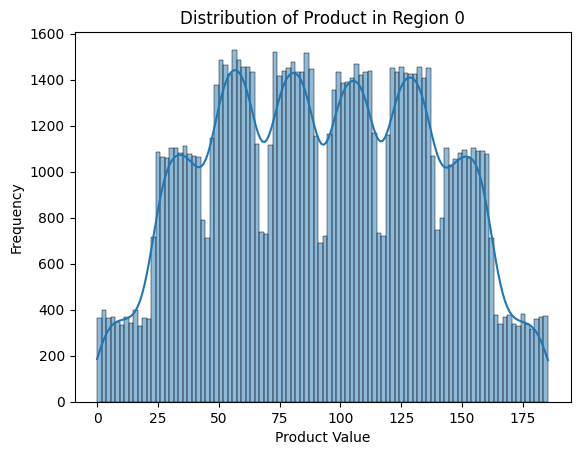

In [208]:
sns.histplot(data= geo_0, 
             bins= 100, 
             x= 'product', 
             kde= True) 

plt.title('Distribution of Product in Region 0') 
plt.xlabel('Product Value') 
plt.ylabel('Frequency')

### 3.2 Geo 1

What's going on here? This is an odd distribution. It looks like multiple small bell curves within a larger bell curve.

In [209]:
display(geo_1.head())
print(f'Rows, columns:\n{geo_1.shape}') 

,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305


Rows, columns:
(100000, 5)


In [210]:
region_1_corr = geo_1.drop(columns='id').corr()
print(region_1_corr)

               f0        f1        f2   product
f0       1.000000  0.182287 -0.001777 -0.030491
f1       0.182287  1.000000 -0.002595 -0.010155
f2      -0.001777 -0.002595  1.000000  0.999397
product -0.030491 -0.010155  0.999397  1.000000


Text(0, 0.5, 'Frequency')

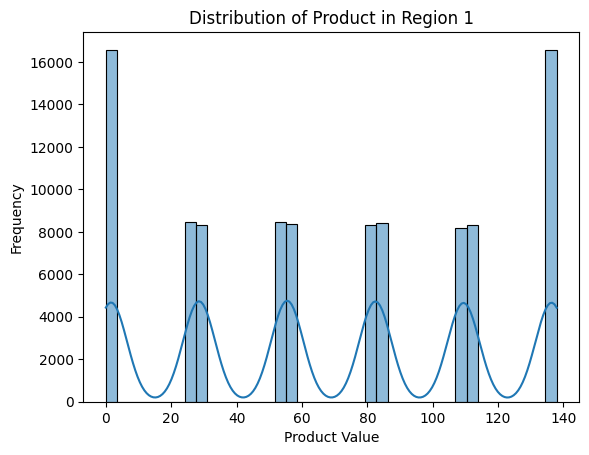

In [211]:
sns.histplot(data= geo_1, 
             x= 'product', 
             kde= True) 
plt.title('Distribution of Product in Region 1') 
plt.xlabel('Product Value') 
plt.ylabel('Frequency') 

### 3.3 Geo 2

In [212]:
display(geo_2.head())
print(f'Rows, columns:\n{geo_2.shape}') 

,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746


Rows, columns:
(100000, 5)


In [213]:
region_2_corr = geo_2.drop(columns='id').corr()
print(region_2_corr)

               f0        f1        f2   product
f0       1.000000  0.000528 -0.000448 -0.001987
f1       0.000528  1.000000  0.000779 -0.001012
f2      -0.000448  0.000779  1.000000  0.445871
product -0.001987 -0.001012  0.445871  1.000000


Text(0, 0.5, 'Frequency')

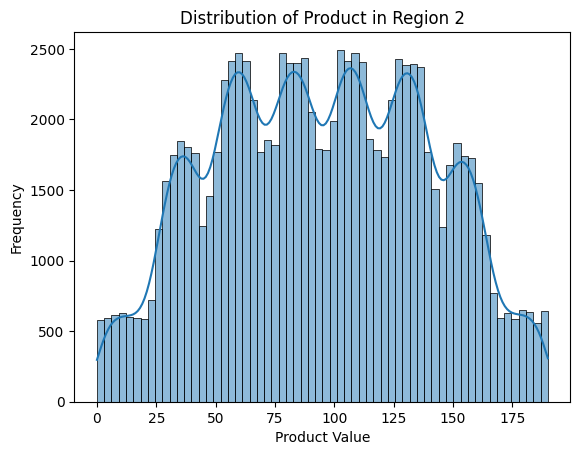

In [214]:
sns.histplot(data= geo_2, 
             x= 'product', 
             kde= True, ) 
plt.title('Distribution of Product in Region 2') 
plt.xlabel('Product Value') 
plt.ylabel('Frequency') 

# 4.0 Model creation 
We'll now create three linear regression models for each region and find the rmse.

### 4.1. Geo 0 Model

In [215]:
state = np.random.RandomState(12345)

features_0 = geo_0.drop(columns=['product', 'id'])
target_0 = geo_0['product']

features_0_train, features_0_valid, target_0_train, target_0_valid = train_test_split(features_0, 
                                                                                      target_0, 
                                                                                      test_size=0.25, 
                                                                                      random_state=state)

In [216]:
model_0 = LinearRegression()
model_0.fit(features_0_train, target_0_train) 
predictions_0 = model_0.predict(features_0_valid)

target_0_valid
predictions_0

predictions_0 = pd.DataFrame(predictions_0, 
                             columns= ['product']) 
predictions_0_mean = predictions_0.mean()

print(f'Predictions:\n{predictions_0},\n\n'f'Avg predicted volume:\n{predictions_0_mean}')

Predictions:
          product
0       95.894952
1       77.572583
2       77.892640
3       90.175134
4       70.510088
...           ...
24995  103.037104
24996   85.403255
24997   61.509833
24998  118.180397
24999  118.169392

[25000 rows x 1 columns],

Avg predicted volume:
product    92.592568
dtype: float64


In [217]:
rmse_0 = mean_squared_error(target_0_valid, predictions_0) ** 0.5 

print(f'RMSE for Geo 0: {rmse_0}')

RMSE for Geo 0: 37.5794217150813


The model suggests that the average predicted volume for `geo_0` is 92.5

### 4.2 Geo 1 Model

In [218]:
features_1 = geo_1.drop(columns= ['product', 'id']) 
target_1 = geo_1['product'] 

features_1_train, features_1_valid, target_1_train, target_1_valid = train_test_split(features_1, 
                                                                                      target_1, 
                                                                                      test_size= 0.25, 
                                                                                      random_state= state) 

model_1 = LinearRegression()
model_1.fit(features_1_train, target_1_train)

predictions_1 = model_1.predict(features_1_valid)
predictions_1 = pd.DataFrame(predictions_1, 
                             columns= ['product'])

predictions_1_mean = predictions_1.mean() 

print(f'Predictions:\n{predictions_1},\n\n'f'Avg predicted volume: {predictions_1_mean}') 

Predictions:
          product
0       54.238152
1       83.217878
2        2.971467
3       25.916480
4      111.341137
...           ...
24995   26.722422
24996   81.570895
24997   83.901769
24998   -1.259473
24999   26.169570

[25000 rows x 1 columns],

Avg predicted volume: product    68.769951
dtype: float64


In [219]:
values_1 = []
for i in range(1000):
    random_seed = state.randint(0, 10000)  # Generate a random seed for each iteration
    subsample_1 = geo_1.sample(frac=1, replace=True, random_state=random_seed)
    numeric_subsample_1 = subsample_1.select_dtypes(include=[np.number])  # Select only numeric columns
    values_1.append(numeric_subsample_1.quantile(q=0.99).values)  

values_1 = pd.DataFrame(values_1, columns=numeric_subsample_1.columns)  

values_1_upper = values_1.quantile(q=0.975) 
values_1_lower = values_1.quantile(q=0.025) 

In [220]:
print(f'Upper quantile:\n{values_1_upper}\n\n', 
      f'Lower quantile:\n{values_1_lower}\n\n')

print(f'rows, columns:\nfeatures_train:\n{features_1_train.shape}\n\n', 
      f'target_train:\n{target_1_train.shape}\n\n', 
      f'features_valid:\n{features_1_valid.shape}\n\n', 
      f'target_valid:\n{target_1_valid.shape}')

Upper quantile:
f0          18.982859
f1           7.243381
f2           5.007944
product    137.945408
Name: 0.975, dtype: float64

 Lower quantile:
f0          18.761459
f1           7.034852
f2           5.007641
product    137.945408
Name: 0.025, dtype: float64


rows, columns:
features_train:
(75000, 3)

 target_train:
(75000,)

 features_valid:
(25000, 3)

 target_valid:
(25000,)


In [221]:
rmse_1 = mean_squared_error(target_1_valid, predictions_1) ** 0.5 

print(f'RMSE for Geo 1: {rmse_1}')

RMSE for Geo 1: 0.889736773768065


### 4.3 Geo 2 Model

In [222]:
features_2 = geo_2.drop(columns= ['product', 'id']) 
target_2 = geo_2['product'] 

features_2_train, features_2_valid, target_2_train, target_2_valid = train_test_split(features_2, 
                                                                                      target_2, 
                                                                                      test_size= 0.25, 
                                                                                      random_state= state) 

model_2 = LinearRegression() 
model_2.fit(features_2_train, target_2_train) 

predictions_2 = model_2.predict(features_2_valid)
predictions_2 = pd.DataFrame(predictions_2, 
                             columns= ['product'])
predictions_2_mean = model_2.predict(features_2_valid).mean() 

print(f'Predictions:\n{predictions_2},\n\n'f'Avg predicted volume: {predictions_2_mean}')

Predictions:
          product
0      100.945722
1       80.901088
2       71.858166
3       92.553389
4       67.210195
...           ...
24995   80.520281
24996   93.548804
24997  111.863928
24998  126.041872
24999   57.360557

[25000 rows x 1 columns],

Avg predicted volume: 94.9342727967311


In [223]:
values_2 = []
for i in range(1000):
    subsample = geo_2.sample(frac=1, replace=True, random_state=state)
    numeric_subsample = subsample.select_dtypes(include=[np.number]) 
    values_2.append(numeric_subsample.quantile(q=0.99).values)  

values_2 = pd.DataFrame(values_2, columns=numeric_subsample.columns)  

values_2_upper = values_2.quantile(q=0.975) 
values_2_lower = values_2.quantile(q=0.025)

In [224]:
print(f'Upper quantile:\n{values_2_upper}\n\n', 
      f'Lower quantile:\n{values_2_lower}\n\n')

print(f'rows, columns:\n{features_2_train}:\n{features_2_train.shape}\n\n', 
      f'target_train:\n{target_2_train.shape}\n\n', 
      f'features_valid:\n{features_2_valid.shape}\n\n', 
      f'target_valid:\n{target_2_valid.shape}')

Upper quantile:
f0           4.095642
f1           4.063393
f2          10.578295
product    185.328101
Name: 0.975, dtype: float64

 Lower quantile:
f0           4.018579
f1           3.985882
f2          10.433315
product    184.648544
Name: 0.025, dtype: float64


rows, columns:
             f0        f1        f2
71413 -0.269914  0.027845  0.561485
47542 -0.411747 -2.250441  4.124997
31452  1.571190 -1.978253  5.392108
50045  1.725798  3.515537  3.584006
6388  -1.754160 -1.529946  8.108507
...         ...       ...       ...
53708 -0.967308  2.637792  0.160747
53276  0.629148 -3.177217  5.029556
35022 -0.346958  1.763027  3.040367
33643 -0.747041 -0.235618 -1.480739
86813  0.328334 -1.951400  7.192655

[75000 rows x 3 columns]:
(75000, 3)

 target_train:
(75000,)

 features_valid:
(25000, 3)

 target_valid:
(25000,)


In [225]:
predictions_2_valid = model_2.predict(features_2_valid)
rmse_2 = mean_squared_error(target_2_valid, predictions_2_valid) ** 0.5 

print(f'RMSE for Geo 2: {rmse_2}')  

RMSE for Geo 2: 39.97347917648822


The Average predicted reserves (formatted to two decimal places) for each region is 92.60, 68.77, 94.93. The respective RMSEs for each region (also formatted to two decimal places) is 37.58, 0.89, 39.97. What this tells us is that `geo_0` and `geo_2` both have a high volume of reserves, but there is a high level of error; the reverse is true for `geo_1`.

# 5.0 Profit Calculation 
Now it's time to find what our profits are. First let's define the budget, revenue per unit, the number of wells to be built, and the amount of money alotted to build a well.

In [226]:
budget = 10**8 
revenue_per_unit = 4500
num_of_wells = 200 
price_per_point = budget // num_of_wells
print(f'Price per point: ${price_per_point}')

Price per point: $500000


Average revenue per well in a region:

In [227]:
print(f'Avg volume for Geo_0:\n{geo_0['product'].mean() * 4500}\n\n', 
      f'Avg volume for Geo_1:\n{geo_1['product'].mean() * 4500}\n\n', 
      f'Avg volume for Geo_2:\n{geo_2['product'].mean() * 4500}\n\n') 

Avg volume for Geo_0:
416250.00000000006

 Avg volume for Geo_1:
309712.50000000006

 Avg volume for Geo_2:
427500.0000000002




Our models suggested that `geo_1` was the underperformer, and the above calculations support that suggestion. What volume of reserves is needed to offset the costs of building these wells?

In [228]:
break_even = price_per_point / revenue_per_unit

print(f'Volume of reserves in thousands of barrels needed to break even:\n{break_even}')

Volume of reserves in thousands of barrels needed to break even:
111.11111111111111


In [229]:
def top_predictions(predictions, n=200): 
    predictions_sorted = sorted(predictions, reverse=True) 
    best_predictions = predictions_sorted[:n]
    return best_predictions

n = 200
top_predictions_0 = top_predictions(predictions_0['product'], n)
top_predictions_1 = top_predictions(predictions_1['product'], n)
top_predictions_2 = top_predictions(predictions_2['product'], n)

In [230]:
print('Prediction description for top 200 wells in each region:')
print(f'Geo 0:\n{pd.Series(top_predictions_0).describe()}\n\n', 
      f'Geo 1:\n{pd.Series(top_predictions_1).describe()}\n\n', 
      f'Geo_2:\n{pd.Series(top_predictions_2).describe()}')

Prediction description for top 200 wells in each region:
Geo 0:
count    200.000000
mean     155.511654
std        6.351371
min      148.365941
25%      150.739383
50%      153.783724
75%      158.576864
max      180.180713
dtype: float64

 Geo 1:
count    200.000000
mean     138.748768
std        0.283047
min      138.423680
25%      138.529010
50%      138.708956
75%      138.859059
max      139.984575
dtype: float64

 Geo_2:
count    200.000000
mean     148.464644
std        4.824836
min      142.763654
25%      144.854680
50%      147.022512
75%      151.678377
max      165.942904
dtype: float64


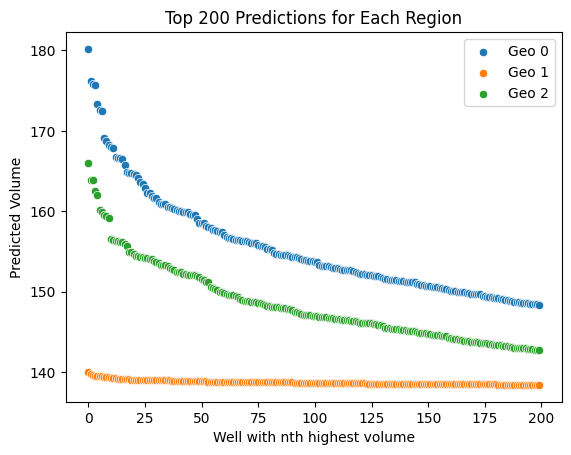

In [231]:
top_predictions_0_df = pd.DataFrame(top_predictions_0, columns=['product'])
top_predictions_1_df = pd.DataFrame(top_predictions_1, columns=['product'])
top_predictions_2_df = pd.DataFrame(top_predictions_2, columns=['product'])

sns.scatterplot(data=top_predictions_0_df, y='product', x=top_predictions_0_df.index)
sns.scatterplot(data=top_predictions_1_df, y='product', x=top_predictions_1_df.index)
sns.scatterplot(data=top_predictions_2_df, y='product', x=top_predictions_2_df.index) 

plt.title('Top 200 Predictions for Each Region') 
plt.xlabel('Well with nth highest volume') 
plt.ylabel('Predicted Volume')
plt.legend(['Geo 0', 'Geo 1', 'Geo 2'])

In [232]:
def convert_to_series(*args):
      return [pd.Series(arg) for arg in args]

top_predictions_0, top_predictions_1, top_predictions_2 = convert_to_series(top_predictions_0, 
                                                                            top_predictions_1, 
                                                                            top_predictions_2)

In [233]:
def predictions_profit(predictions): 
    return (predictions.mean() - break_even) * revenue_per_unit 

predictions_profit_0, predictions_profit_1, predictions_profit_2 = [predictions_profit(top_predictions_0), 
                                                                    predictions_profit(top_predictions_1), 
                                                                    predictions_profit(top_predictions_2)] 

print(f'Predicted mean profit per well per region:\nGeo 0: ${predictions_profit_0:.2f}\nGeo 1: ${predictions_profit_1:.2f}\nGeo 2: ${predictions_profit_2:.2f}')

Predicted mean profit per well per region:
Geo 0: $199802.44
Geo 1: $124369.46
Geo 2: $168090.90


In [234]:
def predicted_region_profits(*args): 
    return [arg * 200 for arg in args] 

predicted_region_profits_0, predicted_region_profits_1, predicted_region_profits_2 = predicted_region_profits(predictions_profit_0, 
                                                                                                              predictions_profit_1, 
                                                                                                              predictions_profit_2) 
print(f'Predicted mean profit per region:\nGeo 0: ${predicted_region_profits_0:.2f}\nGeo 1: ${predicted_region_profits_1:.2f}\nGeo 2: ${predicted_region_profits_2:.2f}')

Predicted mean profit per region:
Geo 0: $39960488.77
Geo 1: $24873891.35
Geo 2: $33618179.31


# 6.0 Profit and Risk

In [235]:
def bootstrap_profit(predictions, target, count=1000):
    profits = []
    for _ in range(count):
        sample = np.random.choice(len(predictions), 
                                  size=len(predictions), 
                                  replace=True)
        sample_predictions = predictions[sample]
        sample_target = target[sample]
        total_profit = (sample_target.sum() * 4500) - (200 * 1_000_000)
        profits.append(total_profit)
    return profits 

In [236]:
profits_region_0, profits_region_1, profits_region_2 = [bootstrap_profit(predictions_0['product'].values, target_0.values), 
                                                        bootstrap_profit(predictions_1['product'].values, target_1.values), 
                                                        bootstrap_profit(predictions_2['product'].values, target_2.values)] 

print(profits_region_0, profits_region_1, profits_region_2)

[np.float64(10223953770.263336), np.float64(10257559070.930546), np.float64(10209462872.626503), np.float64(10274029040.647438), np.float64(10316436282.367205), np.float64(10273364650.209885), np.float64(10214943898.749128), np.float64(10237576030.522575), np.float64(10259257058.957916), np.float64(10272060148.464115), np.float64(10221827481.721468), np.float64(10254471329.380196), np.float64(10321581015.492743), np.float64(10292845299.269339), np.float64(10235367066.879992), np.float64(10245665553.963408), np.float64(10301308290.030083), np.float64(10215492767.876959), np.float64(10223454760.016422), np.float64(10259243286.178637), np.float64(10263179729.341427), np.float64(10279013387.29178), np.float64(10270313422.275385), np.float64(10263703133.386444), np.float64(10225473522.213984), np.float64(10283281433.830793), np.float64(10188903224.552402), np.float64(10236410371.898794), np.float64(10275651141.08875), np.float64(10265692366.174015), np.float64(10243027901.082907), np.float6

In [237]:
def calculate_statistics(profits):
    average_profit = np.mean(profits)
    lower_bound = np.percentile(profits, 2.5)
    upper_bound = np.percentile(profits, 97.5)
    risk_of_loss = np.mean(np.array(profits) < 0) * 100
    return average_profit, (lower_bound, upper_bound), risk_of_loss

In [238]:
profit_confidence_interval_0, profit_confidence_interval_1, profit_confidence_interval_2 = [calculate_statistics(profits_region_0), 
                                                                                            calculate_statistics(profits_region_1), 
                                                                                            calculate_statistics(profits_region_2)] 

print(profit_confidence_interval_0, 
      profit_confidence_interval_1, 
      profit_confidence_interval_2
      )

(np.float64(10252324613.837128), (np.float64(10193283734.873575), np.float64(10314252767.986406)), np.float64(0.0)) (np.float64(7510615530.135979), (np.float64(7447652881.964514), np.float64(7575295149.965689)), np.float64(0.0)) (np.float64(10472964908.82971), (np.float64(10412365244.430344), np.float64(10534967927.360703)), np.float64(0.0))


In [239]:
def loss_probability(*args): 
    return [(np.mean(np.array(arg) < 0) * 100) for arg in args] 

loss_probability_0, loss_probability_1, loss_probability_2 = loss_probability(profits_region_0, 
                                                                              profits_region_1, 
                                                                              profits_region_2) 

print(loss_probability_0, loss_probability_1, loss_probability_2) 

0.0 0.0 0.0


In [240]:
loss_probability_0 = np.mean(np.array(profits_region_0) < 0) * 100
loss_probability_1 = np.mean(np.array(profits_region_1) < 0) * 100
loss_probability_2 = np.mean(np.array(profits_region_2) < 0) * 100